In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
df=pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.head(2)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [5]:
df=df.dropna()

In [6]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder


In [7]:
for i in df.columns:
    if(df[i].dtype=='object'):
        print(i)

Name
Sex
Ticket
Cabin
Embarked


In [8]:
df=df.drop(['Name','Ticket','Cabin','PassengerId'],axis=1)

In [9]:
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
1,1,1,female,38.0,1,0,71.2833,C
3,1,1,female,35.0,1,0,53.1000,S
6,0,1,male,54.0,0,0,51.8625,S


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  183 non-null    int64  
 1   Pclass    183 non-null    int64  
 2   Sex       183 non-null    object 
 3   Age       183 non-null    float64
 4   SibSp     183 non-null    int64  
 5   Parch     183 non-null    int64  
 6   Fare      183 non-null    float64
 7   Embarked  183 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 12.9+ KB


In [11]:
le=LabelEncoder()

df['Sex']=le.fit_transform(df['Sex'])
df['Fare'] =df['Fare'].astype(int)
df=pd.get_dummies(df,columns=['Embarked'])
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
1,1,1,0,38.0,1,0,71,True,False,False
3,1,1,0,35.0,1,0,53,False,False,True
6,0,1,1,54.0,0,0,51,False,False,True
10,1,3,0,4.0,1,1,16,False,False,True
11,1,1,0,58.0,0,0,26,False,False,True
...,...,...,...,...,...,...,...,...,...,...
871,1,1,0,47.0,1,1,52,False,False,True
872,0,1,1,33.0,0,0,5,False,False,True
879,1,1,0,56.0,0,1,83,True,False,False
887,1,1,0,19.0,0,0,30,False,False,True


In [12]:
df.groupby('Survived')['Age'].mean()

Survived
0    41.350000
1    32.905854
Name: Age, dtype: float64

In [13]:
df.groupby(pd.cut(df['Age'], bins=[0,12,18,35,60,100]))['Survived'].mean()

/tmp/ipykernel_16/2538951532.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Age'], bins=[0,12,18,35,60,100]))['Survived'].mean()


Age
(0, 12]      0.818182
(12, 18]     0.916667
(18, 35]     0.761194
(35, 60]     0.602410
(60, 100]    0.200000
Name: Survived, dtype: float64

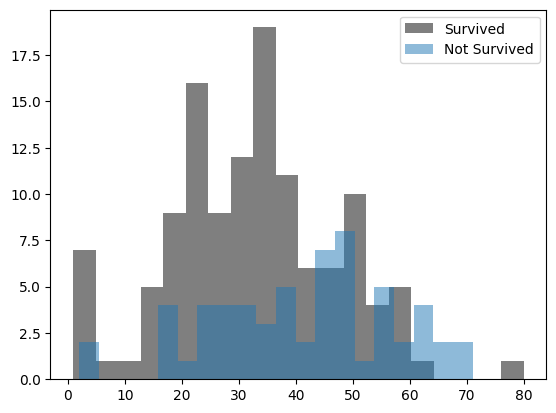

In [14]:
import matplotlib.pyplot as plt 

plt.hist(df[df['Survived']==1]['Age'],bins=20,alpha=0.5,label='Survived',color='black')
plt.hist(df[df['Survived']==0]['Age'],bins=20,alpha=0.5, label='Not Survived')
plt.legend()
plt.show()

In [15]:
df['AgeGroup']=pd.cut(df['Age'],bins=[0,12,18,35,60,100],labels=['Child','Teen','Youngadult','Adult','Old_person'])

df=pd.get_dummies(df,columns=['AgeGroup'])

In [16]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Youngadult,AgeGroup_Adult,AgeGroup_Old_person
1,1,1,0,38.0,1,0,71,True,False,False,False,False,False,True,False
3,1,1,0,35.0,1,0,53,False,False,True,False,False,True,False,False
6,0,1,1,54.0,0,0,51,False,False,True,False,False,False,True,False
10,1,3,0,4.0,1,1,16,False,False,True,True,False,False,False,False
11,1,1,0,58.0,0,0,26,False,False,True,False,False,False,True,False


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Survived             183 non-null    int64  
 1   Pclass               183 non-null    int64  
 2   Sex                  183 non-null    int64  
 3   Age                  183 non-null    float64
 4   SibSp                183 non-null    int64  
 5   Parch                183 non-null    int64  
 6   Fare                 183 non-null    int64  
 7   Embarked_C           183 non-null    bool   
 8   Embarked_Q           183 non-null    bool   
 9   Embarked_S           183 non-null    bool   
 10  AgeGroup_Child       183 non-null    bool   
 11  AgeGroup_Teen        183 non-null    bool   
 12  AgeGroup_Youngadult  183 non-null    bool   
 13  AgeGroup_Adult       183 non-null    bool   
 14  AgeGroup_Old_person  183 non-null    bool   
dtypes: bool(8), float64(1), int64(6)
memory usage

In [18]:
bool_coln = df.select_dtypes(include='bool').columns


In [19]:
df[bool_coln]= df[bool_coln].astype(int)

In [20]:
df[bool_coln]

,Embarked_C,Embarked_Q,Embarked_S,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Youngadult,AgeGroup_Adult,AgeGroup_Old_person
1,1,0,0,0,0,0,1,0
3,0,0,1,0,0,1,0,0
6,0,0,1,0,0,0,1,0
10,0,0,1,1,0,0,0,0
11,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...
871,0,0,1,0,0,0,1,0
872,0,0,1,0,0,1,0,0
879,1,0,0,0,0,0,1,0
887,0,0,1,0,0,1,0,0


In [21]:
df['Age']=df['Age'].astype(int)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 183 entries, 1 to 889
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Survived             183 non-null    int64
 1   Pclass               183 non-null    int64
 2   Sex                  183 non-null    int64
 3   Age                  183 non-null    int64
 4   SibSp                183 non-null    int64
 5   Parch                183 non-null    int64
 6   Fare                 183 non-null    int64
 7   Embarked_C           183 non-null    int64
 8   Embarked_Q           183 non-null    int64
 9   Embarked_S           183 non-null    int64
 10  AgeGroup_Child       183 non-null    int64
 11  AgeGroup_Teen        183 non-null    int64
 12  AgeGroup_Youngadult  183 non-null    int64
 13  AgeGroup_Adult       183 non-null    int64
 14  AgeGroup_Old_person  183 non-null    int64
dtypes: int64(15)
memory usage: 22.9 KB


In [23]:
X=df.drop('Survived',axis=1)
y=df['Survived']


In [24]:
from sklearn.feature_selection import SelectKBest,chi2

In [25]:
selection=SelectKBest(score_func=chi2,k=5)
print(selection)


SelectKBest(k=5, score_func=<function chi2 at 0x7994d99f2200>)


In [26]:
X_new=selection.fit_transform(X,y)

In [27]:
X_new.shape

(183, 5)

In [28]:
X.shape

(183, 14)

In [29]:
select_features=X.columns[selection.get_support()]

In [30]:
print("Top 10 features")
print(*select_features)

Top 10 features
Sex Age Fare AgeGroup_Teen AgeGroup_Old_person


In [31]:
X_new=pd.DataFrame(X_new,columns=select_features)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [33]:
X_train,X_test,Y_train,Y_test= train_test_split(X_new,y,test_size=0.2, random_state=42)

In [34]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train,Y_train)

LogisticRegression(max_iter=1000)

In [35]:
from sklearn.metrics import accuracy_score,classification_report


In [36]:
y_pred=model.predict(X_test)

In [37]:
print(f"The accuracy score is {accuracy_score(Y_test,y_pred)}")

The accuracy score is 0.7567567567567568


In [38]:
Ranmodel=RandomForestClassifier()
Ranmodel.fit(X_train,Y_train)

RandomForestClassifier()

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(max_depth=3,min_samples_split=20),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [40]:
for name,model in models.items():
    model.fit(X_train,Y_train)
    y_pred=model.predict(X_test)
    acc= accuracy_score(Y_test,y_pred)
    print(f"The Accuracy score of {name} is {acc}\n")

The Accuracy score of Logistic Regression is 0.7567567567567568

The Accuracy score of Random Forest is 0.7567567567567568

The Accuracy score of Decision Tree is 0.8108108108108109

The Accuracy score of SVM is 0.6216216216216216

The Accuracy score of KNN is 0.6486486486486487



In [41]:
from sklearn.model_selection import cross_val_score

for name,model in models.items():
    scores=cross_val_score(model,X_new,y,cv=5)
    print(f"{name:<20}->Mean Accuracy:{scores.mean(): .4f}")

Logistic Regression ->Mean Accuracy: 0.7590
Random Forest       ->Mean Accuracy: 0.7483
Decision Tree       ->Mean Accuracy: 0.7422
SVM                 ->Mean Accuracy: 0.6721
KNN                 ->Mean Accuracy: 0.6224


In [42]:
df1=pd.read_csv('/kaggle/input/competitions/titanic/test.csv')
df1.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [43]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# load test
df1 = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

# fill missing values
df1['Age'] = df1['Age'].fillna(df1['Age'].median())
df1['Fare'] = df1['Fare'].fillna(df1['Fare'].median())
df1['Embarked'] = df1['Embarked'].fillna(df1['Embarked'].mode()[0])

# drop columns
df1 = df1.drop(['Name','Ticket','Cabin'], axis=1)

# encode
le = LabelEncoder()
df1['Sex'] = le.fit_transform(df1['Sex'])
df1 = pd.get_dummies(df1, columns=['Embarked'])

# age group
df1['AgeGroup'] = pd.cut(df1['Age'], bins=[0,12,18,35,60,100],
                        labels=['Child','Teen','Youngadult','Adult','Old_person'])
df1 = pd.get_dummies(df1, columns=['AgeGroup'])

# bool → int
bool_cols = df1.select_dtypes(include='bool').columns
df1[bool_cols] = df1[bool_cols].astype(int)

# type conversion
df1['Age'] = df1['Age'].astype(int)
df1['Fare'] = df1['Fare'].astype(int)

# align columns with training data
df1 = df1.reindex(columns=X.columns, fill_value=0)

# apply SelectKBest and keep dataframe format (FIXED WARNING)
X_test_final = pd.DataFrame(
    selection.transform(df1),
    columns=X.columns[selection.get_support()]
)

# predict
y_pred = model.predict(X_test_final)

# submission
submission = pd.DataFrame({
    "PassengerId": pd.read_csv('/kaggle/input/competitions/titanic/test.csv')['PassengerId'],
    "Survived": y_pred
})

submission.to_csv("submission.csv", index=False)